In [1]:
import pymongo
connectionString= "mongodb://10.29.162.146:27017/"
import sys
sys.path.append('../..')
import src.encryption 
import src.channelCoding
import src.utils




myclient = pymongo.MongoClient(connectionString)
mydb = myclient[f"r0_r1_SC_alpha_0_5_R=0_5_Encryption"]
collection=mydb[f'destination, phase_1']

/home/moh/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "
2025-09-02 06:23:50.453224: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-09-02 06:23:50.466606: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1756812230.480472 2871035 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for

In [2]:
sample = collection.find_one({})
sample.keys()

dict_keys(['_id', 'time_stamp', 'BER_tag', 'BER_msg', 'r0', 'r1', 'SNR', 'sigma_n2', 'config', 'enc_conf'])

In [3]:
conf = src.config.CONFIG()
payload_bits = src.utils.string_to_bits(conf.PAYLOAD)
payload_encoded_bits = src.channelCoding.encode_LDPC(payload_bits, 2*len(payload_bits)) 

key = sample['enc_conf']['KEY']
iv = sample['enc_conf']['IV']
cnt = sample['enc_conf']['COUNTER']

hex_msg, _ = src.encryption.AESCTRAligned.get_range(
        bytes.fromhex(key),
        bytes.fromhex(iv),
        chunk_bits=len(sample['r0']),
        index=cnt,
        return_int=True
    )

rand_bits = src.utils.hex_to_bits(hex_msg.hex())





I0000 00:00:1756812232.440401 2871035 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 19999 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3090, pci bus id: 0000:01:00.0, compute capability: 8.6


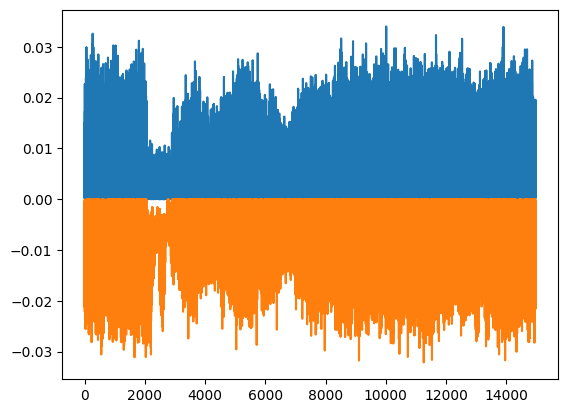

In [4]:
import matplotlib.pyplot as plt
import numpy as np

plt.plot(sample['r1'])
plt.plot(-1*np.array(sample['r0']))

In [24]:
enc_cypher_txt = np.array(sample['r1']) > np.array(sample['r0'])
print(int(len(enc_cypher_txt)*conf.MSG_CODE_RATE), len(enc_cypher_txt))
import tensorflow as tf

enc_cypher_txt =msg = tf.constant(enc_cypher_txt, dtype=tf.float32)
print(enc_cypher_txt.get_shape())
decoded = src.channelCoding.decode_LDPC(enc_cypher_txt, int(len(sample['r0'])*conf.MSG_CODE_RATE))

src.utils.bits_to_string(decoded)


7488 14976
(14976,)


'ñ¾ß\x8b\x97O\x9b\x1b±Ão4Ç\x7fÞøfc`r¿s´\x17\x08\x8eÍåu·ØtÏf~\x18«¤\x85\xadÙþÛþÉ)Úñ¿ö\\"º·½æÝeû)\x89øâ¯þ5ïoûoýÇûvÏ];ïïG\x1d¼Û/ÿsµ\x9d»¯\x8f®Ý\x12Ò\x84\x84\x96\x18\x92Û\x04¨W\x8b\x97\x98_\x9f\x88\x81\r\x02\x93\x97_#\x9eÐ\x83\x12\n\t\x06\x98\x80\x04Ê\x89\x95\x02Ý¯\x9e\x9aë\x8dq^\x8eÀ\x92ß\x96\x88z\x8dAKÝ»\x9aÇÝ\x8c\x97\x8f\x8cë\x16\x90±ð\x91Ëà\'[Øà»Ó\x97n\x8a\x108D\x0f\x90\x8d\x0e\tÆ\x1e\x95é°Æ©\x9f÷nÉ\x8c\x9d\x19\x1fVÓ×L\x9b\x9e×ÿ\x98\x97\x85\x8c\x8f×Þ\x9cÔ\x98\x08Ï\x9cÇ\x88O»\x90\x0c\x183º\x92\x1e\x99×\r¿\x0f»þ»û=\x86\x8f·ú\x08\n\x86\x86Ç\x7fß»÷\x90\x94\x97¾\x98îç\x1fÊAÛò\x0c\x97\xad\x1f\x1aÚÛ\x9a\x91¶\x92\x91\x03_Ï\x86\x9eÛ\x8dÎ\x87Ý\x9c\x8d\x8d\x8a\x8a\x93\x96ß\x8a\x17\x8bÛ¿ÓÅ\x9e¡\x19\x9e\x8e\x0fÿíÚvÚ\x0b·Ã\x85\x1cû\x83®\x03\x0c\x901\x10Áß"\x80V*\n\x13GÛ\x1fºß\x07ÁÇ:\x8c¯ûÿ£ëîºÎ÷ÿ\x8eýÚ\x8f¦L\x7fþý»ïýu¬Ê¤ßNÌÿ÷}ÿ÷VßwN;ëÿ¥ûközï?Ö\x03¼GXH\x17½#þ*ëçï¿ëãM\x97nñ·ÿTô×íß\x8c;½öÚ½n¯o~ò¯Þw¾òV\x06î÷õ/wïæ\'üüýÏïÄ¥\x98õ\x94+PÌi\x05µ+\x91Ãfà\xa0¤\x13Ú\x12À3\x93,¨\x7f]C[ûºê\x9d=y\x9f<õÞx\x9f\x90\x9